<a href="https://colab.research.google.com/github/VictorNevola/ml-study/blob/main/ml_08_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predicted class for the new point: {1: np.int64(0), 15: np.int64(1)}
OK: the point changes class between the two k values.

Charts saved as .png and .svg successfully!

Other good candidate points: [(np.float64(0.62), np.float64(-0.35)), (np.float64(0.67), np.float64(-0.35)), (np.float64(0.62), np.float64(-0.25)), (np.float64(0.72), np.float64(-0.3)), (np.float64(0.77), np.float64(-0.25))]


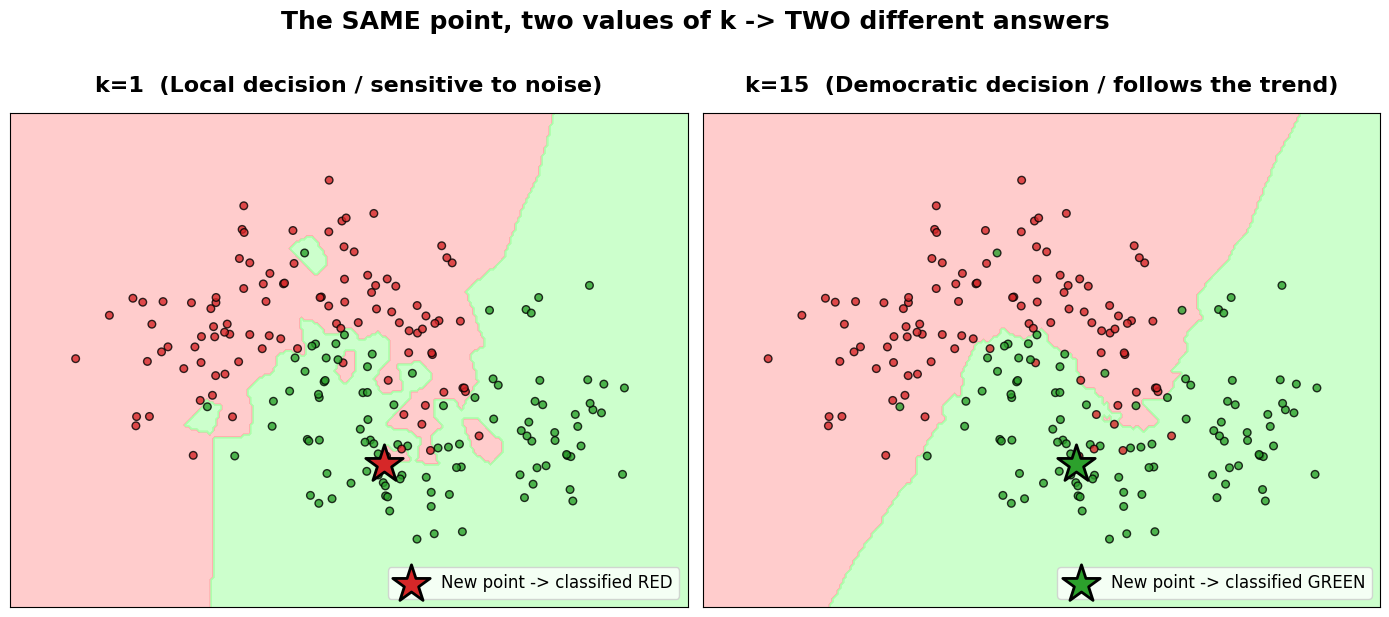

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier

# 1. Dataset with a complex pattern and some noise
X, y = make_moons(n_samples=200, noise=0.3, random_state=42)

# K values to compare
k_values = [1, 15]

# The strategic "new point" that CHANGES class depending on k.
# NOTE: (0.5, 0.4) does NOT flip -- it is class 1 for both k=1 and k=15.
# (0.62, -0.35) sits inside a noisy pocket: k=1 takes the noise seriously (red),
# while k=15 ignores it and follows the real trend (green).
new_point = np.array([[0.62, -0.35]])

# --- Sanity check: does the point actually flip? -----------------------------
preds = {k: KNeighborsClassifier(n_neighbors=k).fit(X, y).predict(new_point)[0]
         for k in k_values}
print("Predicted class for the new point:", preds)
if len(set(preds.values())) == 1:
    print("WARNING: the point does NOT change class -- the slide loses its point!")
    print("         Pick another point (or run find_flipping_points() below).")
else:
    print("OK: the point changes class between the two k values.\n")
# -----------------------------------------------------------------------------

# 2. Plot colors
cmap_background = ListedColormap(['#FFAAAA', '#AAFFAA'])  # light red / light green (regions)
cmap_points = ListedColormap(['#D62728', '#2CA02C'])      # strong red / strong green (data)

# Mesh grid used to draw the decision boundary
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

titles = ["k=1  (Local decision / sensitive to noise)",
          "k=15  (Democratic decision / follows the trend)"]

plt.figure(figsize=(14, 6))

for i, k in enumerate(k_values):
    # Train the KNN model
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y)

    # Predict over the whole mesh (paints the background)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Prediction for the new point specifically
    new_pred = clf.predict(new_point)[0]
    new_point_color = '#D62728' if new_pred == 0 else '#2CA02C'
    class_name = 'RED' if new_pred == 0 else 'GREEN'

    # Plot
    plt.subplot(1, 2, i + 1)
    plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points,
                edgecolor='k', s=30, alpha=0.8)

    # Highlight the new point with a giant star
    plt.scatter(new_point[:, 0], new_point[:, 1], c=new_point_color, marker='*',
                s=800, edgecolor='black', linewidth=2, zorder=5,
                label=f'New point -> classified {class_name}')

    plt.title(titles[i], fontsize=16, fontweight='bold', pad=15)
    plt.legend(loc='lower right', fontsize=12)
    plt.xticks(())
    plt.yticks(())

plt.suptitle("The SAME point, two values of k -> TWO different answers",
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('knn_comparacao_k1_k15.png', dpi=300, bbox_inches='tight')
plt.savefig('knn_comparacao_k1_k15.svg', format='svg', bbox_inches='tight')
print("Charts saved as .png and .svg successfully!")


# --- Helper: find points that flip class between the two k values -------------
def find_flipping_points(X, y, k_low=1, k_high=15, top=5):
    """Scan the grid and return points that change class between k_low and k_high,
    preferring dense regions (where the demo is most convincing)."""
    from scipy.spatial import cKDTree

    clf_low = KNeighborsClassifier(n_neighbors=k_low).fit(X, y)
    clf_high = KNeighborsClassifier(n_neighbors=k_high).fit(X, y)

    xs = np.arange(X[:, 0].min(), X[:, 0].max(), 0.05)
    ys = np.arange(X[:, 1].min(), X[:, 1].max(), 0.05)
    grid = np.array([[a, b] for a in xs for b in ys])

    flips = grid[clf_low.predict(grid) != clf_high.predict(grid)]
    if len(flips) == 0:
        return []

    # prefer dense areas: small distance to the k_high-th neighbor
    dist, _ = cKDTree(X).query(flips, k=k_high)
    order = np.argsort(dist[:, -1])
    return [tuple(np.round(flips[i], 2)) for i in order[:top]]


if __name__ == "__main__":
    print("\nOther good candidate points:", find_flipping_points(X, y))


#Cell1

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("diabetes_en.csv")
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 614 | Test: 154


In [3]:
for k in [1, 3, 5]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    pipe.fit(X_train, y_train)
    print(f"k={k}:  train = {pipe.score(X_train, y_train):.3f}"
          f"  |  test = {pipe.score(X_test, y_test):.3f}")

k=1:  train = 1.000  |  test = 0.708
k=3:  train = 0.863  |  test = 0.695
k=5:  train = 0.806  |  test = 0.701


In [4]:
k_values = range(1, 32, 2)   # odd numbers avoid ties in the vote
scores = []

for k in k_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    score = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy").mean()
    scores.append(score)

for k, s in zip(k_values, scores):
    print(f"k={k:2d} -> {s:.3f}")

k= 1 -> 0.717
k= 3 -> 0.722
k= 5 -> 0.744
k= 7 -> 0.746
k= 9 -> 0.749
k=11 -> 0.748
k=13 -> 0.759
k=15 -> 0.757
k=17 -> 0.749
k=19 -> 0.748
k=21 -> 0.749
k=23 -> 0.751
k=25 -> 0.757
k=27 -> 0.749
k=29 -> 0.764
k=31 -> 0.767


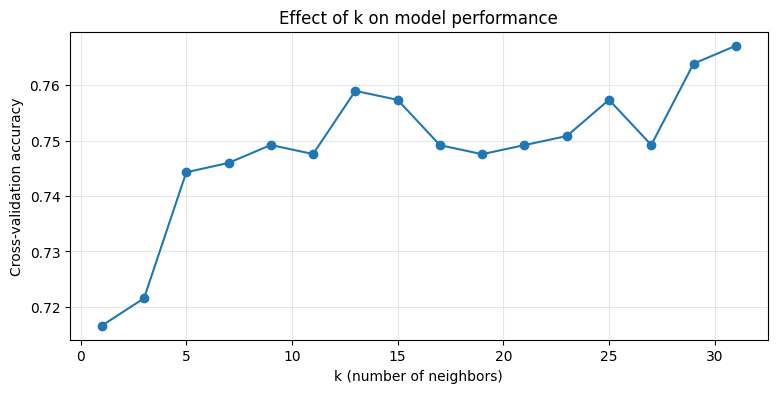

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(list(k_values), scores, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Cross-validation accuracy")
plt.title("Effect of k on model performance")
plt.grid(alpha=0.3)
plt.show()

In [11]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=13)),
])
model.fit(X_train, y_train)

new_patient = pd.DataFrame([{
    "pregnancies": 2, "glucose": 170, "blood_pressure": 74,
    "skin_thickness": 30, "insulin": 100, "bmi": 35.0,
    "diabetes_pedigree": 0.6, "age": 45
}])

proba = model.predict_proba(new_patient)[0]
print(f"Vote among the 13 neighbors:")
print(f"  no diabetes: {proba[0]:.0%}")
print(f"  diabetes:    {proba[1]:.0%}")
print(f"\nFinal prediction: {'HAS diabetes' if model.predict(new_patient)[0] == 1 else 'no diabetes'}")

Vote among the 13 neighbors:
  no diabetes: 23%
  diabetes:    77%

Final prediction: HAS diabetes


In [13]:
# WITHOUT scaling
knn_raw = KNeighborsClassifier(n_neighbors=13)
knn_raw.fit(X_train, y_train)

# WITH scaling (inside a pipeline)
knn_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=13)),
])
knn_scaled.fit(X_train, y_train)

print(f"KNN WITHOUT scaling: {knn_raw.score(X_test, y_test):.2%}")
print(f"KNN WITH scaling:    {knn_scaled.score(X_test, y_test):.2%}")

KNN WITHOUT scaling: 70.78%
KNN WITH scaling:    75.97%
